In [1]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn wordcloud nltk

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re, string, warnings, pickle, os
warnings.filterwarnings('ignore')

In [2]:
import urllib.request, zipfile

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
urllib.request.urlretrieve(url, "sms.zip")

with zipfile.ZipFile("sms.zip", 'r') as z:
    z.extractall(".")

df = pd.read_csv("SMSSpamCollection", sep='\t', header=None, names=['label', 'message'])
print(df.shape)
print(df['label'].value_counts())
df.head()

(5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


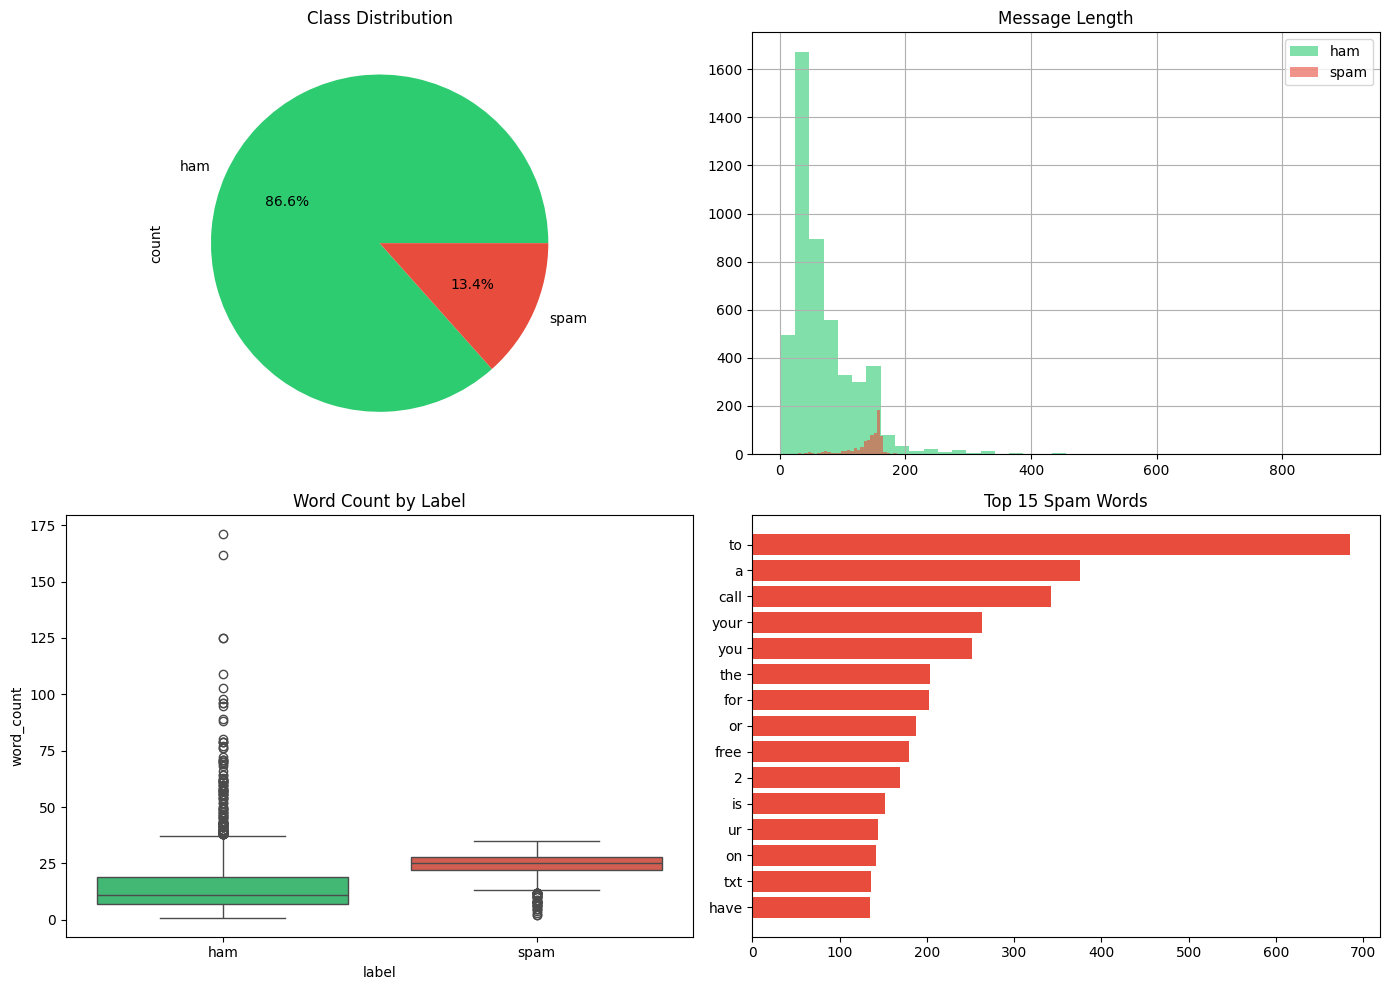

In [3]:
df['msg_length'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df['label'].value_counts().plot.pie(ax=axes[0,0], autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'])
axes[0,0].set_title("Class Distribution")

for label, color in [('ham','#2ecc71'), ('spam','#e74c3c')]:
    df[df['label']==label]['msg_length'].hist(bins=40, alpha=0.6, ax=axes[0,1], label=label, color=color)
axes[0,1].set_title("Message Length")
axes[0,1].legend()

sns.boxplot(data=df, x='label', y='word_count', palette={'ham':'#2ecc71','spam':'#e74c3c'}, ax=axes[1,0])
axes[1,0].set_title("Word Count by Label")

from collections import Counter
spam_words = ' '.join(df[df['label']=='spam']['message']).lower().split()
top15 = Counter(spam_words).most_common(15)
words, counts = zip(*top15)
axes[1,1].barh(words, counts, color='#e74c3c')
axes[1,1].invert_yaxis()
axes[1,1].set_title("Top 15 Spam Words")

plt.tight_layout()
plt.show()

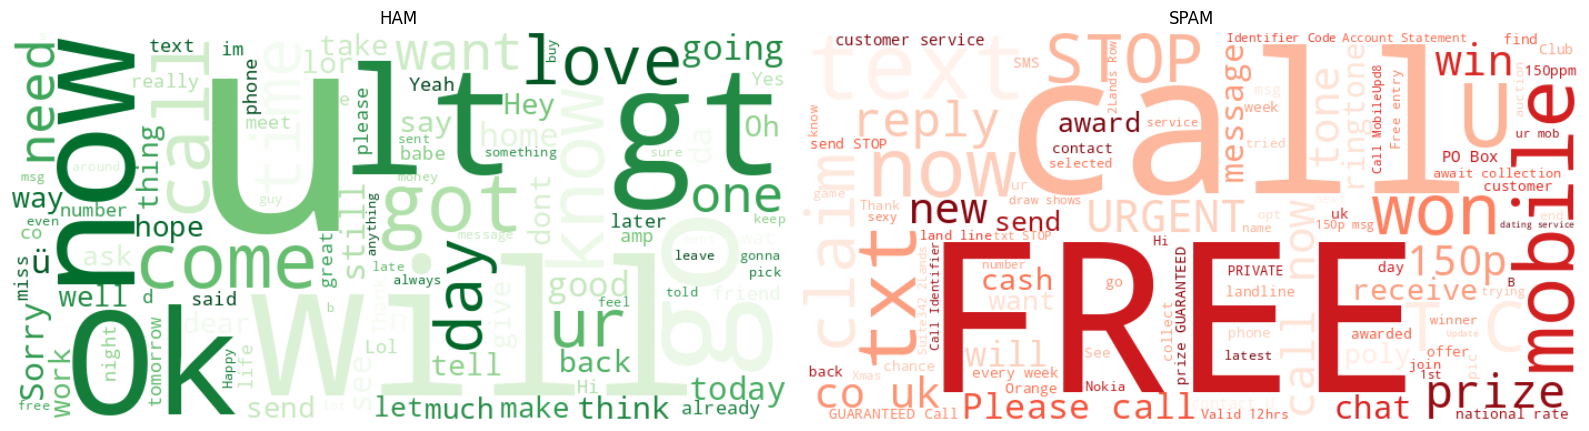

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, label, cmap in [(axes[0],'ham','Greens'), (axes[1],'spam','Reds')]:
    text = ' '.join(df[df['label']==label]['message'])
    wc = WordCloud(width=700, height=350, background_color='white', colormap=cmap, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(label.upper())

plt.tight_layout()
plt.show()

In [17]:
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if len(t) > 1]
    return ' '.join(tokens)

df['clean_message'] = df['message'].apply(clean_text)
df['label_encoded'] = (df['label'] == 'spam').astype(int)
df[['message','clean_message']].head(3)

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in wkly comp to win fa cup final tk...


In [18]:
from sklearn.model_selection import train_test_split

X = df['clean_message']
y = df['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)

(4457,) (1115,)


In [19]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

count_vec = CountVectorizer(max_features=10000, ngram_range=(1,2), min_df=2)
X_train_count = count_vec.fit_transform(X_train)
X_test_count  = count_vec.transform(X_test)

tfidf_vec = TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=2, sublinear_tf=True)
X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf  = tfidf_vec.transform(X_test)

print(X_train_count.shape, X_train_tfidf.shape)

(4457, 10000) (4457, 10000)


In [20]:
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

def train_evaluate(model, X_tr, X_te, y_tr, y_te, name, vec):
    t = time.time()
    model.fit(X_tr, y_tr)
    elapsed = round(time.time() - t, 3)
    y_pred = model.predict(X_te)
    return {
        'Model': name,
        'Vectorizer': vec,
        'Accuracy':  round(accuracy_score(y_te, y_pred)*100, 2),
        'Precision': round(precision_score(y_te, y_pred)*100, 2),
        'Recall':    round(recall_score(y_te, y_pred)*100, 2),
        'F1':        round(f1_score(y_te, y_pred)*100, 2),
        'Time(s)':   elapsed
    }

configs = [
    (MultinomialNB(alpha=0.1),                          "MultinomialNB",       "CountVec", X_train_count, X_test_count),
    (ComplementNB(alpha=0.1),                           "ComplementNB",        "CountVec", X_train_count, X_test_count),
    (MultinomialNB(alpha=0.1),                          "MultinomialNB",       "TF-IDF",   X_train_tfidf, X_test_tfidf),
    (ComplementNB(alpha=0.1),                           "ComplementNB",        "TF-IDF",   X_train_tfidf, X_test_tfidf),
    (LogisticRegression(C=1.0, max_iter=1000, random_state=42), "LogisticRegression", "TF-IDF", X_train_tfidf, X_test_tfidf),
    (LinearSVC(C=1.0, random_state=42),                "LinearSVC",           "TF-IDF",   X_train_tfidf, X_test_tfidf),
]

rows = []
trained = {}

for model, name, vec, X_tr, X_te in configs:
    row = train_evaluate(model, X_tr, X_te, y_train, y_test, name, vec)
    rows.append(row)
    trained[f"{name}_{vec}"] = model

results_df = pd.DataFrame(rows).sort_values('F1', ascending=False)
results_df

,Model,Vectorizer,Accuracy,Precision,Recall,F1,Time(s)
5,LinearSVC,TF-IDF,98.48,97.83,90.60,94.08,0.018
2,MultinomialNB,TF-IDF,98.03,98.47,86.58,92.14,0.003
0,MultinomialNB,CountVec,97.85,94.96,88.59,91.67,0.004
1,ComplementNB,CountVec,97.22,88.82,90.60,89.70,0.003
3,ComplementNB,TF-IDF,97.04,87.66,90.60,89.11,0.003
4,LogisticRegression,TF-IDF,96.95,100.00,77.18,87.12,0.037


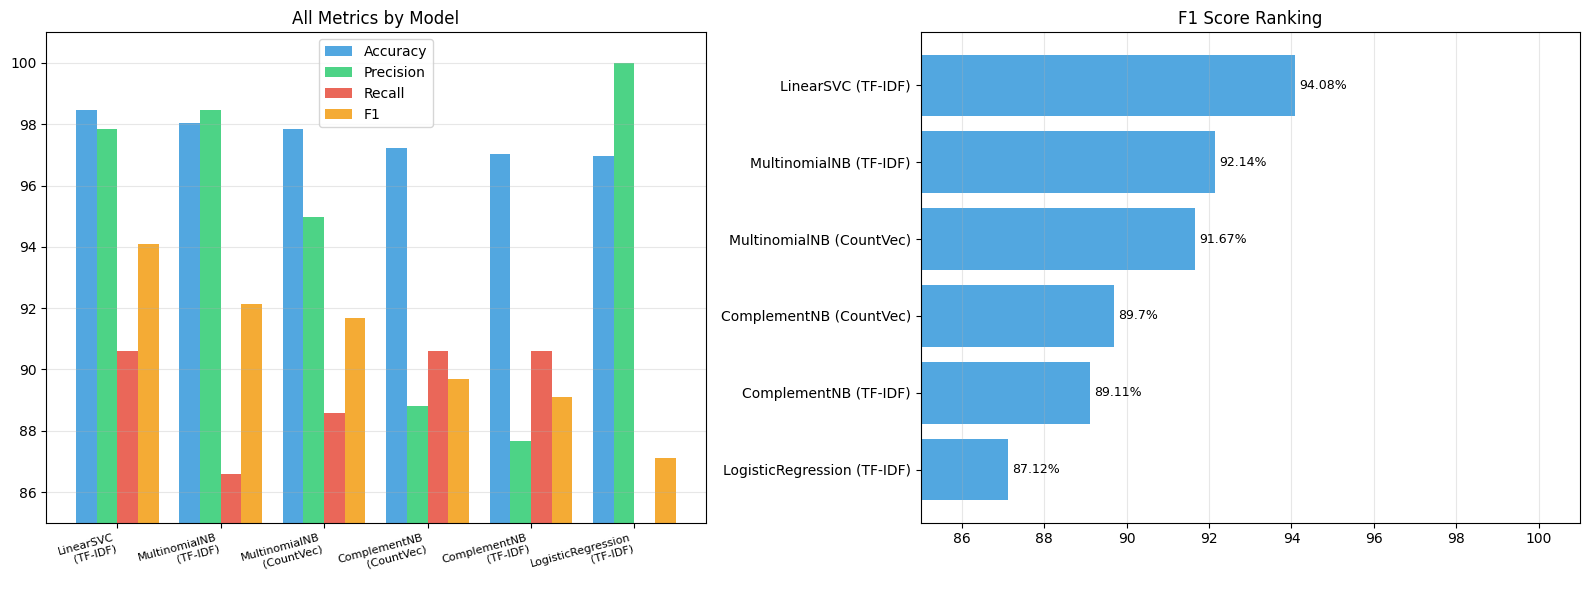

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics = ['Accuracy','Precision','Recall','F1']
x = np.arange(len(results_df))
width = 0.2
colors = ['#3498db','#2ecc71','#e74c3c','#f39c12']

for i, (m, c) in enumerate(zip(metrics, colors)):
    axes[0].bar(x + i*width, results_df[m].astype(float), width, label=m, color=c, alpha=0.85)

axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels([f"{r['Model']}\n({r['Vectorizer']})" for _, r in results_df.iterrows()], fontsize=8, rotation=15, ha='right')
axes[0].set_ylim(85, 101)
axes[0].legend()
axes[0].set_title("All Metrics by Model")
axes[0].grid(axis='y', alpha=0.3)

f1_sorted = results_df.sort_values('F1')
labels = [f"{r['Model']} ({r['Vectorizer']})" for _, r in f1_sorted.iterrows()]
axes[1].barh(labels, f1_sorted['F1'], color='#3498db', alpha=0.85)
axes[1].set_xlim(85, 101)
for i, v in enumerate(f1_sorted['F1']):
    axes[1].text(v+0.1, i, f"{v}%", va='center', fontsize=9)
axes[1].set_title("F1 Score Ranking")
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

         HAM       0.99      1.00      0.99       966
        SPAM       0.98      0.91      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.97      1115
weighted avg       0.98      0.98      0.98      1115



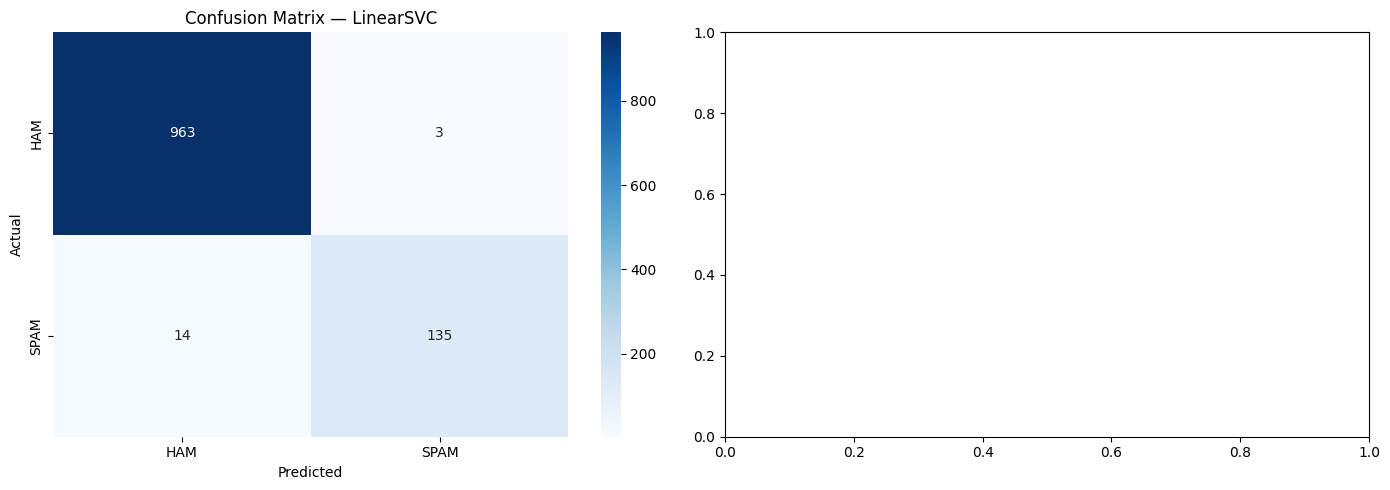

In [22]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

best_name = results_df.iloc[0]['Model']
best_vec  = results_df.iloc[0]['Vectorizer']
best_model = trained[f"{best_name}_{best_vec}"]

X_te = X_test_tfidf if best_vec == 'TF-IDF' else X_test_count
y_pred = best_model.predict(X_te)

print(classification_report(y_test, y_pred, target_names=['HAM','SPAM']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['HAM','SPAM'], yticklabels=['HAM','SPAM'])
axes[0].set_title(f"Confusion Matrix — {best_name}")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

if hasattr(best_model, 'predict_proba'):
    proba = best_model.predict_proba(X_te)[:,1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[1].plot([0,1],[0,1],'--', color='gray')
    axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
    axes[1].set_title("ROC Curve")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True)),
    ('clf',   LogisticRegression(random_state=42, max_iter=1000))
])

param_grid = {
    'tfidf__max_features': [8000, 15000],
    'tfidf__ngram_range':  [(1,1), (1,2)],
    'clf__C':              [0.1, 1.0, 10.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print(grid.best_params_)
print(round(grid.best_score_*100, 2))

best_pipeline = grid.best_estimator_
y_pred_tuned = best_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_tuned, target_names=['HAM','SPAM']))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
{'clf__C': 10.0, 'tfidf__max_features': 15000, 'tfidf__ngram_range': (1, 2)}
93.32
              precision    recall  f1-score   support

         HAM       0.98      1.00      0.99       966
        SPAM       0.99      0.89      0.94       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [24]:
import json
from datetime import datetime

with open('spam_pipeline.pkl', 'wb') as f:
    pickle.dump(best_pipeline, f)

meta = {
    "model": "LogisticRegression + TF-IDF",
    "created": datetime.now().isoformat(),
    "best_params": grid.best_params_,
    "f1_cv": round(grid.best_score_*100, 2),
    "f1_test": round(f1_score(y_test, y_pred_tuned)*100, 2),
    "precision": round(precision_score(y_test, y_pred_tuned)*100, 2),
    "recall": round(recall_score(y_test, y_pred_tuned)*100, 2),
}

with open('model_meta.json', 'w') as f:
    json.dump(meta, f, indent=4)

print(meta)

{'model': 'LogisticRegression + TF-IDF', 'created': '2026-05-31T10:27:22.194542', 'best_params': {'clf__C': 10.0, 'tfidf__max_features': 15000, 'tfidf__ngram_range': (1, 2)}, 'f1_cv': np.float64(93.32), 'f1_test': 93.62, 'precision': 99.25, 'recall': 88.59}


In [29]:
def predict(messages, threshold=0.3):
    with open('spam_pipeline.pkl', 'rb') as f:
        model = pickle.load(f)
    
    if isinstance(messages, str):
        messages = [messages]
    
    cleaned = [clean_text(m) for m in messages]
    probs   = model.predict_proba(cleaned)
    preds   = ['SPAM' if p[1] >= threshold else 'HAM' for p in probs]
    
    return pd.DataFrame({
        'message':    messages,
        'prediction': preds,
        'spam_prob':  [round(p[1]*100, 1) for p in probs],
        'ham_prob':   [round(p[0]*100, 1) for p in probs],
    })

msgs = [
    "Congratulations you won a free iPhone click now",
    "Hey are we still meeting tomorrow at 1pm",
    "URGENT your account suspended verify now",
    "Can you send me the notes from class",
    "FREE entry WIN 1000 cash text WIN to 87121",
]

predict(msgs, threshold=0.3)

,message,prediction,spam_prob,ham_prob
0,Congratulations you won a free iPhone click now,SPAM,89.4,10.6
1,Hey are we still meeting tomorrow at 1pm,HAM,0.5,99.5
2,URGENT your account suspended verify now,SPAM,64.0,36.0
3,Can you send me the notes from class,HAM,1.6,98.4
4,FREE entry WIN 1000 cash text WIN to 87121,SPAM,98.2,1.8
